<a href="https://colab.research.google.com/github/HeatherNankunda/electric-vehicle-energy-demand-forecasting/blob/main/Final_Project_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [86]:
df = pd.read_csv("/content/drive/MyDrive/Electric_Vehicle_(EV)_Charging_Data_-_Municipal_Lots_and_Garages_20260406.csv")

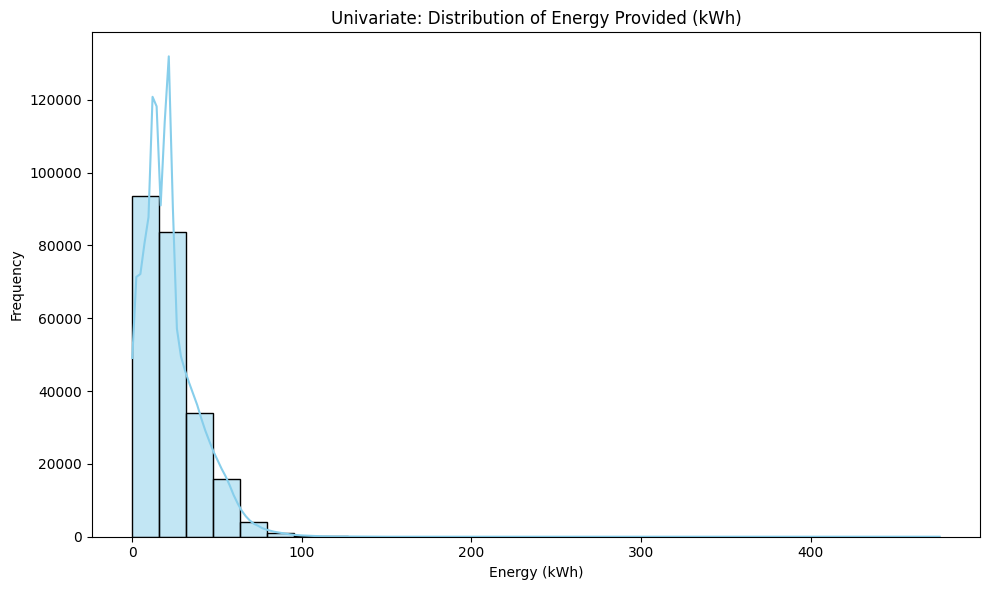

In [29]:
#UNIVARIATE VISUALIZATION 1
plt.figure(figsize=(10, 6))
sns.histplot(df['Energy Provided (kWh)'], bins=30, kde=True, color='skyblue')
plt.title('Univariate: Distribution of Energy Provided (kWh)')
#plt.xticks(np.arange(0, 121, 20))
plt.xlabel('Energy (kWh)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('univariate_energy.png')
plt.show()

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Charge Duration (min)'], bins=30, kde=True, color='salmon')
plt.title('Univariate: Distribution of Charge Duration (min)')
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.savefig('univariate_duration.png')
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x78e1eb145120> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x78e1eb116660> (for post_execute):


KeyboardInterrupt: 

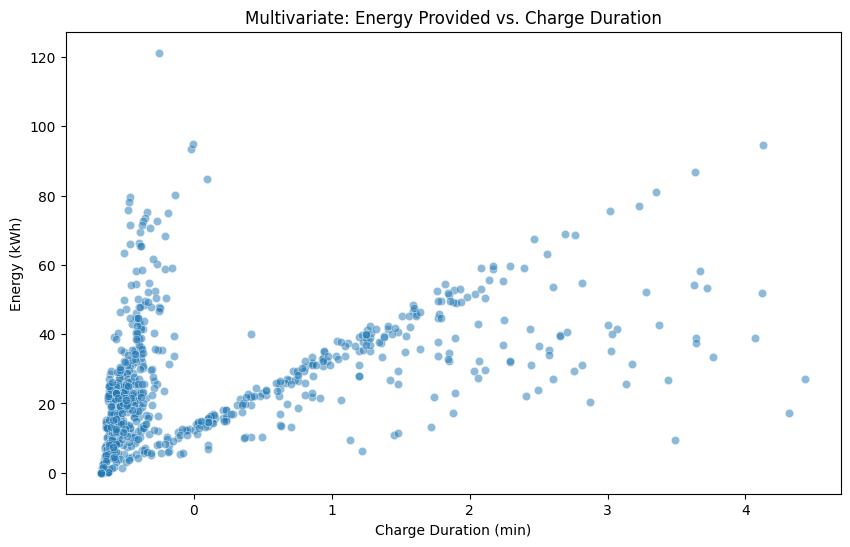

In [24]:
# MULTIVARIATE VISUALIZATION 1
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Charge Duration (min)', y='Energy Provided (kWh)', alpha=0.5)
plt.title('Multivariate: Energy Provided vs. Charge Duration')
plt.xlabel('Charge Duration (min)')
plt.ylabel('Energy (kWh)')
plt.savefig('multivariate_scatter.png')
plt.show()

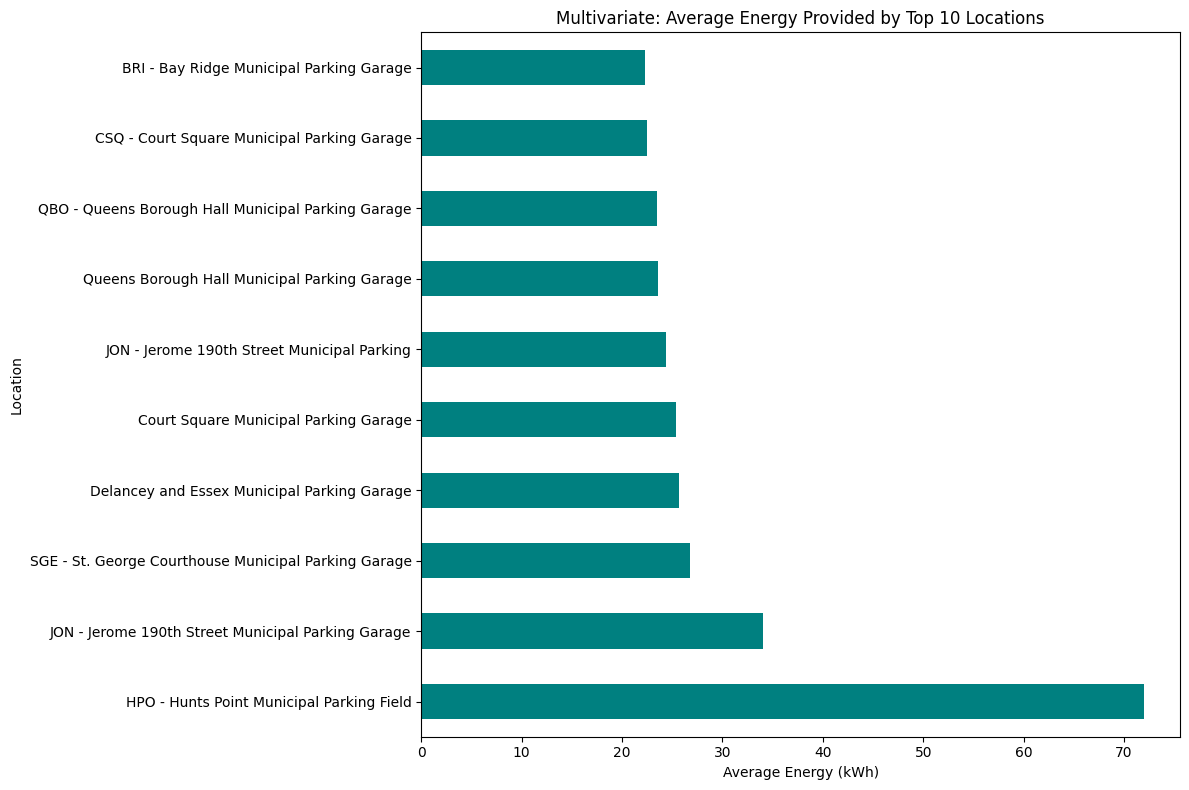

In [8]:
# MULTIVARIATE VISUALIZATION 2
avg_energy_loc = df.groupby('Location Name')['Energy Provided (kWh)'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 8))
avg_energy_loc.plot(kind='barh', color='teal')
plt.title('Multivariate: Average Energy Provided by Top 10 Locations')
plt.xlabel('Average Energy (kWh)')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('multivariate_location.png')
plt.show()

Handling missing Values

In [87]:
# Drop column that is 100% empty
df.drop(columns=['Invalidity Reason'], inplace=True)
# Drop rows where critical info is missing
df.dropna(subset=['Location Name', 'Driver ID'], inplace=True)

Standardizing Data Types

In [88]:
# Convert Duration columns from strings to floats
df['Charge Duration (min)'] = pd.to_numeric(df['Charge Duration (min)'], errors='coerce')
df['Connected Duration (min)'] = pd.to_numeric(df['Connected Duration (min)'], errors='coerce')

# Convert Date and Time to datetime objects
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
# For time, we extract the time component specifically
df['Connected Time'] = pd.to_datetime(df['Connected Time'], format='%H:%M:%S.%f', errors='coerce')

# Drop any rows that failed conversion (NaT/NaN)
df.dropna(subset=['Charge Duration (min)', 'Date', 'Connected Time'], inplace=True)

Feature Engineering (Extraction)

In [89]:
# Extract features from Date
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek  # Monday=0, Sunday=6

# Extract Hour from Connected Time
df['Connected Hour'] = df['Connected Time'].dt.hour

# Example: Create a 'Weekend' flag (Binary)
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

Managing Outliers

In [90]:
# 1. Remove sessions with zero or negative duration
df = df[df['Charge Duration (min)'] > 0]

# 2. Filter out extreme energy outliers (e.g., sessions > 150 kWh)
# Based on common EV battery sizes
energy_cap = 150
df = df[df['Energy Provided (kWh)'] <= energy_cap]

# 3. Sanity check: Energy shouldn't be provided if duration is near zero
df = df[~((df['Energy Provided (kWh)'] > 1) & (df['Charge Duration (min)'] < 1))]

In [91]:
df.describe()

,Date,Connector ID,Connected Time,Charge Duration (min),Connected Duration (min),Energy Provided (kWh),Month,DayOfWeek,Connected Hour,IsWeekend
count,961,961.000000,961,961.000000,947.000000,961.000000,961.0,961.00000,961.000000,961.000000
mean,2025-08-23 15:36:31.467221760,1.388137,1900-01-01 13:07:35.698230784,129.816373,168.225952,23.774644,8.0,3.03538,12.632674,0.312175
min,2025-08-21 00:00:00,1.000000,1900-01-01 00:01:28,0.283333,0.283333,0.001000,8.0,0.00000,0.000000,0.000000
25%,2025-08-22 00:00:00,1.000000,1900-01-01 08:04:30,20.569633,20.908333,12.992000,8.0,1.00000,8.000000,0.000000
50%,2025-08-24 00:00:00,1.000000,1900-01-01 14:03:48,35.883200,36.200000,21.397000,8.0,3.00000,14.000000,0.000000
75%,2025-08-25 00:00:00,2.000000,1900-01-01 18:48:08,149.416667,206.166667,30.958000,8.0,5.00000,18.000000,1.000000
max,2025-08-27 00:00:00,2.000000,1900-01-01 23:58:02,983.000000,983.000000,121.260000,8.0,6.00000,23.000000,1.000000
std,NaN,0.487580,NaN,192.475602,252.255472,16.385245,0.0,2.12593,6.827131,0.463622


Categorical Encoding

In [92]:
# Select the categorical column to encode
location_encoded = pd.get_dummies(df['Location Name'], prefix='Loc')

# Join the encoded columns back to the main dataframe
df = pd.concat([df, location_encoded], axis=1)

Feature Scaling

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Define numerical columns to scale
cols_to_scale = ['Charge Duration (min)', 'Connected Hour', 'Month']

# Apply scaling
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

Defining Variables

In [94]:
# 2. Define Variables
X = df[['Location Name', 'Month', 'DayOfWeek', 'Connected Hour', 'Charge Duration (min)']]
y = df['Energy Provided (kWh)']

Data Preprocessing Pipeline

In [95]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify feature types
numeric_features = ['Month', 'DayOfWeek', 'Connected Hour', 'Charge Duration (min)']
categorical_features = ['Location Name']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        # Scale numbers to have mean=0 and variance=1
        ('num', StandardScaler(), numeric_features),
        # Convert text locations into binary 'One-Hot' columns
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

Splitting the Data

In [96]:
from sklearn.model_selection import train_test_split

# Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples.")

Training on 720 samples, testing on 241 samples.


Modeling

In [97]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor


# 1. Classical Model: Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42))
])
rf_model.fit(X_train, y_train)


# 2. Neural Network: Multi-Layer Perceptron (MLP)
mlp_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
])
mlp_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Month', 'DayOfWeek',
                                                   'Connected Hour',
                                                   'Charge Duration (min)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Location Name'])])),
                ('regressor',
                 MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500,
                              random_state=42))])

In [98]:
from sklearn.pipeline import Pipeline
import joblib

# Replace 'rf_pipeline' with the name of your best-performing model variable
joblib.dump(rf_model, 'ev_model.pkl')

print("Model saved successfully as ev_model.pkl!")

Model saved successfully as ev_model.pkl!


Evaluation Metrics

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Assuming y_test are the actual values and y_pred are the model predictions
def evaluate_model(y_test, y_pred, model_name):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"--- {model_name} Performance ---")
    print(f"1. MAE:  {mae:.2f} kWh")
    print(f"2. MSE:  {mse:.2f}")
    print(f"3. RMSE: {rmse:.2f} kWh")
    print(f"4. R2:   {r2:.4f}")
    print("-" * 30)

# Generate predictions for evaluation
y_pred_rf = rf_model.predict(X_test)
y_pred_mlp = mlp_model.predict(X_test)

# Example usage for your two models:
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_mlp, "Neural Network")

--- Random Forest Performance ---
1. MAE:  7.39 kWh
2. MSE:  118.64
3. RMSE: 10.89 kWh
4. R2:   0.5025
------------------------------
--- Neural Network Performance ---
1. MAE:  8.34 kWh
2. MSE:  131.90
3. RMSE: 11.48 kWh
4. R2:   0.4470
------------------------------


Demo

In [100]:
import gradio as gr
import pandas as pd
import joblib

# --- 1. LOAD THE TRAINED MODEL ---
# Ensure you have saved your model previously: joblib.dump(rf_model, 'ev_model.pkl')
try:
    model = joblib.load('ev_model.pkl')
except:
    model = None

# --- 2. THE PREDICTION FUNCTION ---
def predict_energy(location, month, day_of_week, hour, duration):
    if model is None:
        return "Error: Model file 'ev_model.pkl' not found."

    # Map day of week string to number (Monday=0, Sunday=6)
    days = {"Monday":0, "Tuesday":1, "Wednesday":2, "Thursday":3, "Friday":4, "Saturday":5, "Sunday":6}
    dow_num = days[day_of_week]

    # Create the input dataframe
    input_df = pd.DataFrame({
        'Location Name': [location],
        'Month': [month],
        'DayOfWeek': [dow_num],
        'Connected Hour': [hour],
        'Charge Duration (min)': [duration]
    })

    # Generate prediction
    prediction = model.predict(input_df)[0]

    # Contextual insight for the presentation
    insight = f"\n\n💡 Impact: This energy could power a standard Ugandan LED bulb for {int(prediction * 1000 / 10)} hours."

    return f"{round(prediction, 2)} kWh" + insight

# --- 3. CREATE THE GRADIO INTERFACE ---
# Define the inputs
inputs = [
    gr.Dropdown(
        choices=["JGU - Jerome Gun Hill Road Municipal Parking Garage",
                 "CSQ - Court Square Municipal Parking Garage",
                 "BPL - Brighton Beach Municipal Lot"],
        label="Charging Location"
    ),
    gr.Slider(minimum=1, maximum=12, step=1, value=4, label="Month"),
    gr.Dropdown(
        choices=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
        label="Day of the Week"
    ),
    gr.Slider(minimum=0, maximum=23, step=1, value=10, label="Connection Hour (24h)"),
    gr.Number(label="Charge Duration (Minutes)", value=120)
]

# Define the output
output = gr.Textbox(label="Predicted Energy Requirement")

# Build the App
app = gr.Interface(
    fn=predict_energy,
    inputs=inputs,
    outputs=output,
    title="⚡ EV Energy Demand Predictor",
    description="Input session details below to estimate the total energy (kWh) required. This helps municipal planners in cities like Kampala manage EV infrastructure load.",
    theme="soft"
)

# Launch the App
if __name__ == "__main__":
    app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4d77caca11af825d36.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
